In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r'C:\Users\Kiran\Desktop\Rishabh Mishra\Diwali_Sales_Analysis.csv')

In [3]:
df.shape

(500, 15)

In [4]:
df.head(2)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           500 non-null    int64  
 1   Cust_name         500 non-null    object 
 2   Product_ID        500 non-null    object 
 3   Gender            500 non-null    object 
 4   Age Group         500 non-null    object 
 5   Age               500 non-null    int64  
 6   Marital_Status    500 non-null    int64  
 7   State             500 non-null    object 
 8   Zone              500 non-null    object 
 9   Occupation        500 non-null    object 
 10  Product_Category  500 non-null    object 
 11  Orders            500 non-null    int64  
 12  Amount            488 non-null    float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 58.7+ KB


In [7]:
df = df.drop(['Status','unnamed1'], axis = 1)

In [9]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [11]:
df = df.dropna()

In [12]:
df.shape

(488, 13)

In [23]:
df['Amount'] = df['Amount'].astype('int')

In [14]:
df[['Age', 'Orders', 'Amount']].describe()

,Age,Orders,Amount
count,488.000000,488.000000,488.000000
mean,36.942623,2.477459,20717.585922
std,12.941695,1.129911,1005.649428
min,12.000000,1.000000,19613.000000
25%,28.000000,1.000000,20208.750000
50%,35.000000,2.000000,20500.500000
75%,44.000000,4.000000,20847.750000
max,92.000000,4.000000,23952.000000


In [16]:
df.rename(columns={'Marital_Status':'Shadi'})

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Shadi,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1003105,Ludwig,P00244142,F,36-45,38,1,Bihar,Eastern,Agriculture,Food,4,19617.0
496,1004795,Lonsdale,P00043542,F,46-50,49,0,Bihar,Eastern,Media,Food,2,19617.0
497,1004937,Ferrer,P00169442,F,36-45,43,0,Karnataka,Southern,Aviation,Food,4,19615.0
498,1001050,Nishant,P00162942,F,26-35,31,0,Haryana,Northern,Aviation,Food,1,19614.0


## Exploratory Data Analysis

### Gender

In [19]:
import seaborn as sns

In [20]:
df['Gender'].value_counts()

Gender
F    334
M    154
Name: count, dtype: int64

In [24]:
sales_gender = df.groupby(['Gender'],as_index = False)['Amount'].sum()
sales_gender

,Gender,Amount
0,F,6906971
1,M,3203208


<Axes: xlabel='Gender', ylabel='Amount'>

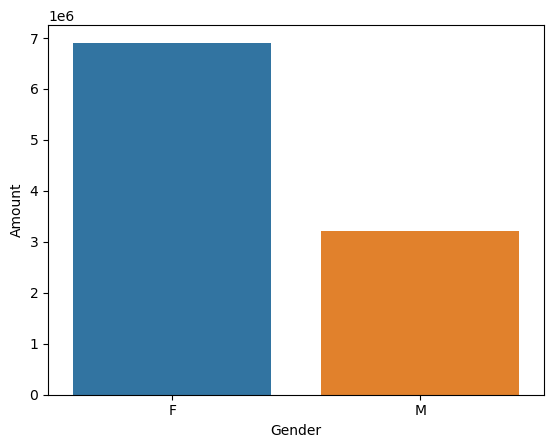

In [26]:
sns.barplot(data = sales_gender, x = 'Gender', y = 'Amount', hue = 'Gender')

#### From above graph we can see that count and purchasing power of females are high.

### Age

In [27]:
df['Age Group'].value_counts()

Age Group
26-35    189
36-45    120
18-25     61
51-55     49
46-50     39
55+       20
0-17      10
Name: count, dtype: int64

<Axes: xlabel='Age Group', ylabel='count'>

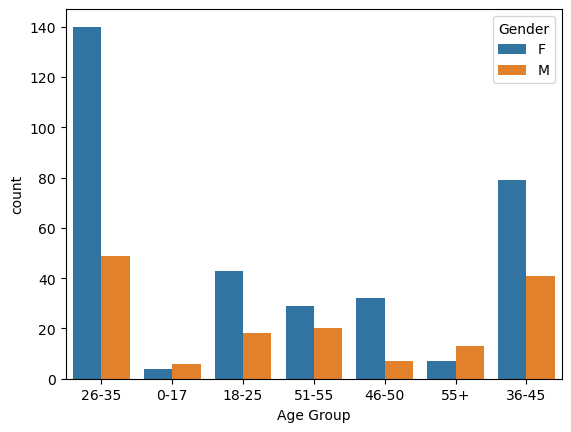

In [31]:
sns.countplot(data = df, x = 'Age Group', hue = 'Gender')

In [33]:
sales_age = df.groupby(['Age Group', 'Gender'], as_index = False)['Amount'].sum()
sales_age

,Age Group,Gender,Amount
0,0-17,F,79783
1,0-17,M,127388
2,18-25,F,899839
3,18-25,M,374596
4,26-35,F,2894708
5,26-35,M,1028395
6,36-45,F,1629387
7,36-45,M,838809
8,46-50,F,661419
9,46-50,M,144930


<Axes: xlabel='Age Group', ylabel='Amount'>

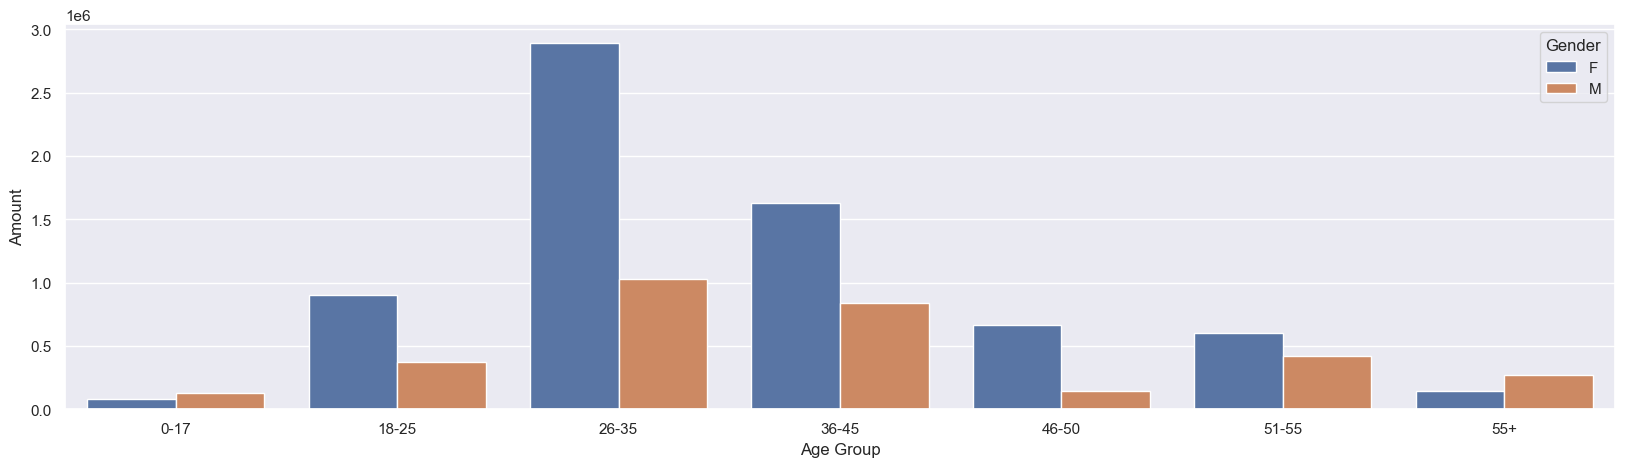

In [72]:
sns.barplot(data = sales_age, x = 'Age Group', y = 'Amount', hue = 'Gender')

#### From above graph we see that females of 26-35 age group making more purchases and purchasing power of them is also high.

### Occupation

In [37]:
df['Occupation'].value_counts()

Occupation
IT Sector          76
Aviation           61
Healthcare         49
Banking            49
Govt               39
Automobile         29
Media              29
Chemical           28
Retail             23
Construction       22
Food Processing    22
Hospitality        20
Lawyer             19
Textile            14
Agriculture         8
Name: count, dtype: int64

In [45]:
sales_occupation = df.groupby(['Occupation'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False)
sales_occupation

,Occupation,Amount
10,IT Sector,1568502
2,Aviation,1264724
3,Banking,1020562
8,Healthcare,1002856
7,Govt,812866
1,Automobile,609543
12,Media,605241
4,Chemical,571685
13,Retail,475055
6,Food Processing,461805


<Axes: xlabel='Occupation', ylabel='Amount'>

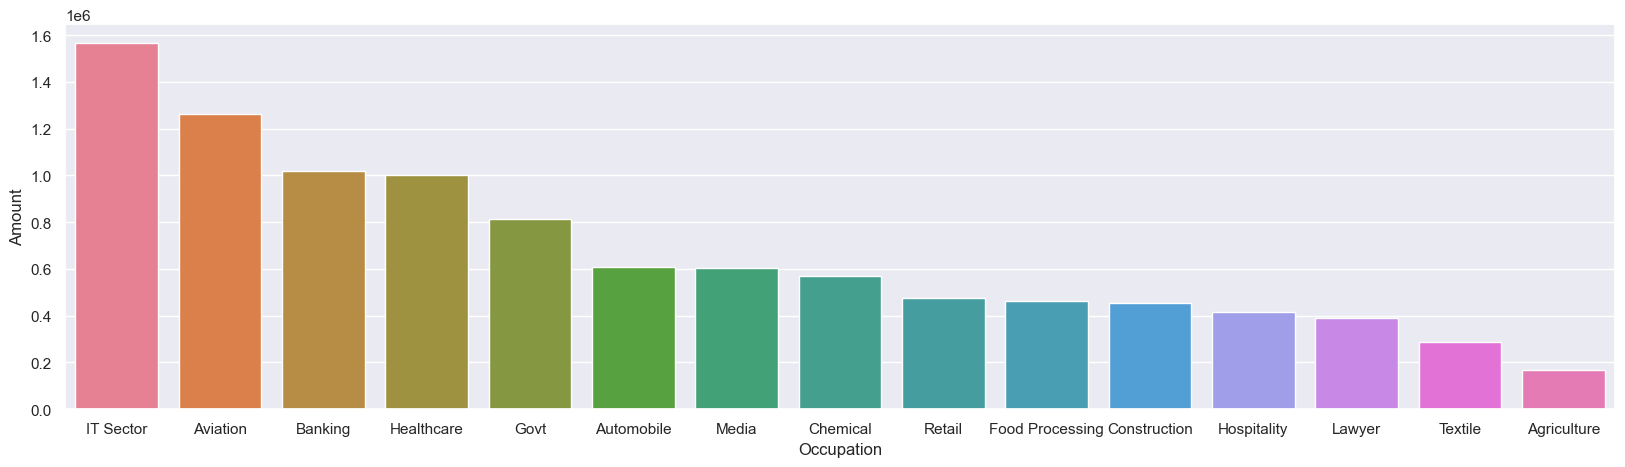

In [77]:
sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_occupation, x = 'Occupation', y = 'Amount', hue = 'Occupation')

#### From above graph and data we can see that more purchases done by IT, Aviation, Healthcare. But as per purchasing power third position is taken by Banking

### Product Category

In [50]:
df['Product_Category'].value_counts()

Product_Category
Footwear & Shoes      224
Furniture             102
Food                   60
Auto                   45
Stationery             31
Tupperware             23
Hand & Power Tools      3
Name: count, dtype: int64

In [54]:
sales_category = df.groupby(['Product_Category'], as_index = False)['Amount'].sum().sort_values(by='Amount', ascending = False)
sales_category

,Product_Category,Amount
2,Footwear & Shoes,4602105
3,Furniture,2066800
1,Food,1179623
0,Auto,1056952
5,Stationery,658382
6,Tupperware,476477
4,Hand & Power Tools,69840


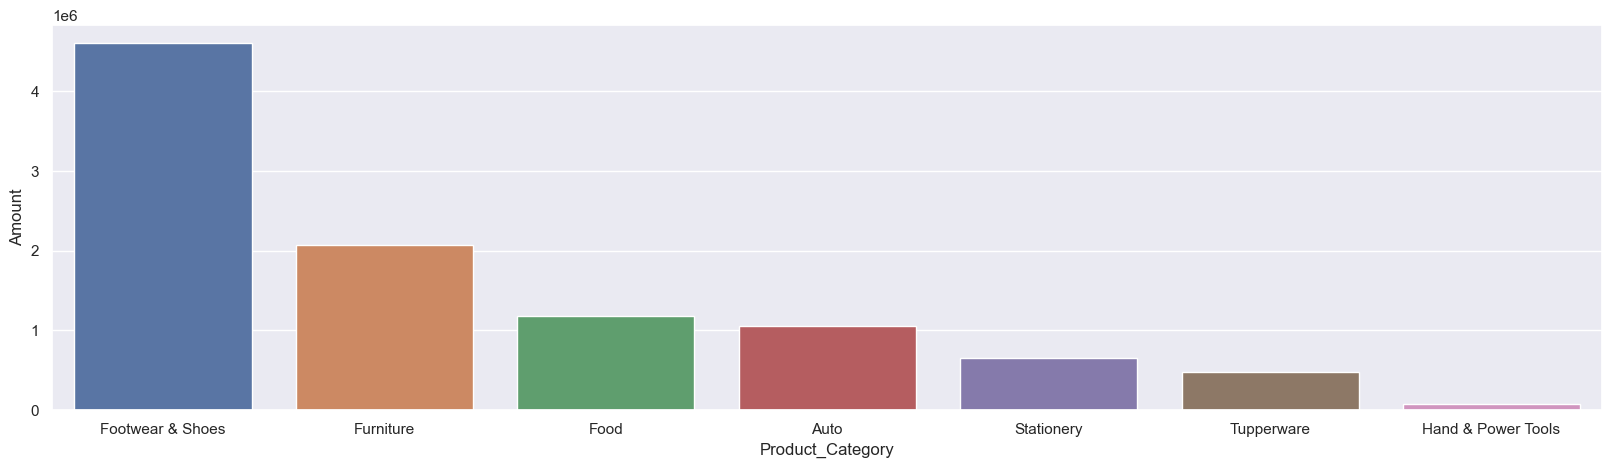

In [57]:
sns.barplot(data = sales_category, x = 'Product_Category', y = 'Amount', hue = 'Product_Category');

#### From above details we can see that more sales is done on Footwear, Furniture and Food.

### State

In [59]:
df['State'].value_counts()

State
Delhi               110
Karnataka            95
Uttar Pradesh        75
Andhra Pradesh       44
Maharashtra          36
Madhya Pradesh       27
Kerala               21
Haryana              18
Himachal Pradesh     13
Gujarat              12
Bihar                11
Uttarakhand          11
Jharkhand             6
Rajasthan             5
Telangana             3
Punjab                1
Name: count, dtype: int64

In [68]:
sales_state = df.groupby(['State'], as_index = False)['Orders'].sum().sort_values(by = 'Orders', ascending = False).head(10)
sales_state                                                                                                                    

,State,Orders
2,Delhi,261
7,Karnataka,237
14,Uttar Pradesh,181
0,Andhra Pradesh,119
10,Maharashtra,90
9,Madhya Pradesh,66
8,Kerala,47
4,Haryana,43
5,Himachal Pradesh,37
1,Bihar,32


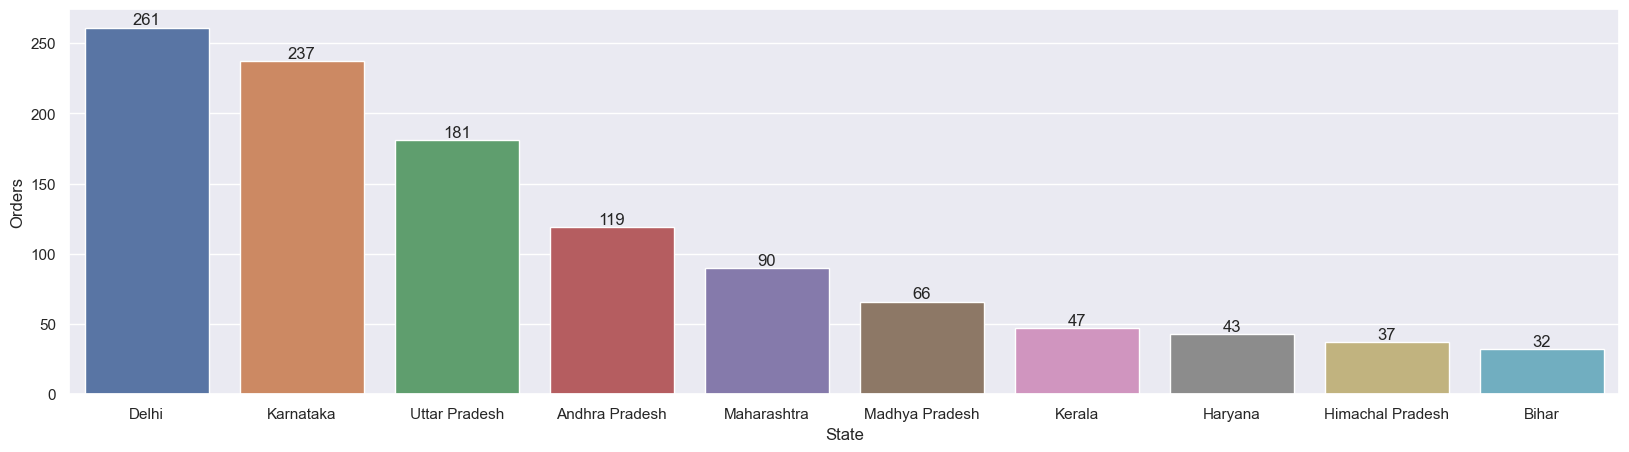

In [69]:
ax = sns.barplot(data = sales_state, x = 'State', y = 'Orders', hue = 'State')
for bars in ax.containers:
    ax.bar_label(bars)

#### We can see that Delhi, Karnataka, UP placing more orders.

### Marital Status

In [78]:
df['Marital_Status'].value_counts()

Marital_Status
0    282
1    206
Name: count, dtype: int64

In [79]:
sales_mstatus = df.groupby(['Marital_Status', 'Gender'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False)
sales_mstatus

,Marital_Status,Gender,Amount
0,0,F,4045922
2,1,F,2861049
1,0,M,1775318
3,1,M,1427890


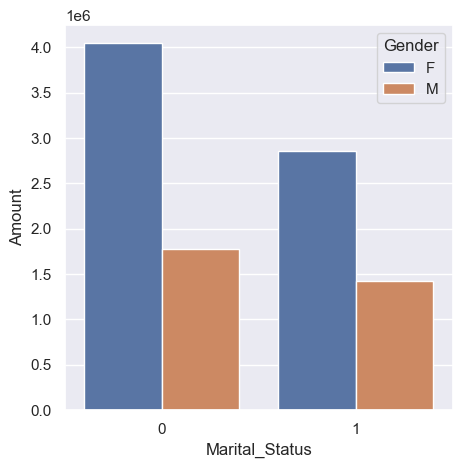

In [84]:
sns.set(rc={'figure.figsize':(5,5)})
ax = sns.barplot(data = sales_mstatus, x = 'Marital_Status', y = 'Amount', hue = 'Gender')

#### From above details we can see that unmarried customers are less still their purchasing power is high.
#### We also see that females are purchasing more compare to male.

### Conclusion :

#### From above details and graphs we conclude that women, 26-35 age group from Delhi, Karnataka, UP working in IT, Aviation, Banking and Healthcare are more likely to buy footwear, furniture and food products. 